In [28]:
import sys
print(sys.version)

3.9.18 (main, Sep 11 2023, 13:30:38) [MSC v.1916 64 bit (AMD64)]


In [29]:
import os
import zipfile
import random
import shutil
import numpy as np
from shutil import copyfile

%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

In [7]:
print(tf.__version__)

2.10.0


In [25]:
import os

base_dir = './dataset_binary'


train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'test') 

print("Checking Train Directory:", train_dir)
try:
    print("Folders found:", os.listdir(train_dir))
except FileNotFoundError:
    print("ERROR: Paths are wrong. Please check where your notebook file is saved relative to the dataset folder.")

Checking Train Directory: ./dataset_binary\train
Folders found: ['fresh', 'rotten']


In [9]:
import os
import shutil

# 1. Define Paths
original_dataset_dir = './dataset'
base_dir = './dataset_binary' 


def organize_binary_data(source_root, dest_root):
    
    os.makedirs(os.path.join(dest_root, 'fresh'), exist_ok=True)
    os.makedirs(os.path.join(dest_root, 'rotten'), exist_ok=True)

    # Walk through the original subfolders (freshapples, rottenbanana, etc.)
    for subfolder in os.listdir(source_root):
        source_path = os.path.join(source_root, subfolder)
        
        # Skip if it's not a folder
        if not os.path.isdir(source_path): continue

        
        if 'fresh' in subfolder.lower():
            target_folder = 'fresh'
        elif 'rotten' in subfolder.lower():
            target_folder = 'rotten'
        else:
            continue 

        print(f"Processing {subfolder} -> Merging into {target_folder}...")
        
        # Copy the images
        dest_path = os.path.join(dest_root, target_folder)
        for filename in os.listdir(source_path):
            src_file = os.path.join(source_path, filename)
            dst_file = os.path.join(dest_path, filename)
            # Only copy if it doesn't exist yet (saves time on re-runs)
            if not os.path.exists(dst_file):
                shutil.copy(src_file, dst_file)

# 3. Run the organization for Train and Test
print("Organizing Training Data...")
organize_binary_data(os.path.join(original_dataset_dir, 'train'), os.path.join(base_dir, 'train'))

print("\nOrganizing Validation Data...")
organize_binary_data(os.path.join(original_dataset_dir, 'test'), os.path.join(base_dir, 'test'))

print("\nDone! New binary dataset created at './dataset_binary'")

Organizing Training Data...
Processing freshapples -> Merging into fresh...
Processing freshbanana -> Merging into fresh...
Processing freshoranges -> Merging into fresh...
Processing rottenapples -> Merging into rotten...
Processing rottenbanana -> Merging into rotten...
Processing rottenoranges -> Merging into rotten...

Organizing Validation Data...
Processing freshapples -> Merging into fresh...
Processing freshbanana -> Merging into fresh...
Processing freshoranges -> Merging into fresh...
Processing rottenapples -> Merging into rotten...
Processing rottenbanana -> Merging into rotten...
Processing rottenoranges -> Merging into rotten...

Done! New binary dataset created at './dataset_binary'


In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.2, #0.2, 0.5
    height_shift_range=0.2, #0.2, 0.5
    shear_range=0.2,
    zoom_range=[0.5, 1.0], # 0.2, 0.5, [0.5,1.0]
    rotation_range=90, #20, 40, 60, 90
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect' #nearest, reflect, wrap
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

Testing augmentation on: ./dataset_binary\train\fresh\rotated_by_15_Screen Shot 2018-06-08 at 4.59.36 PM.png


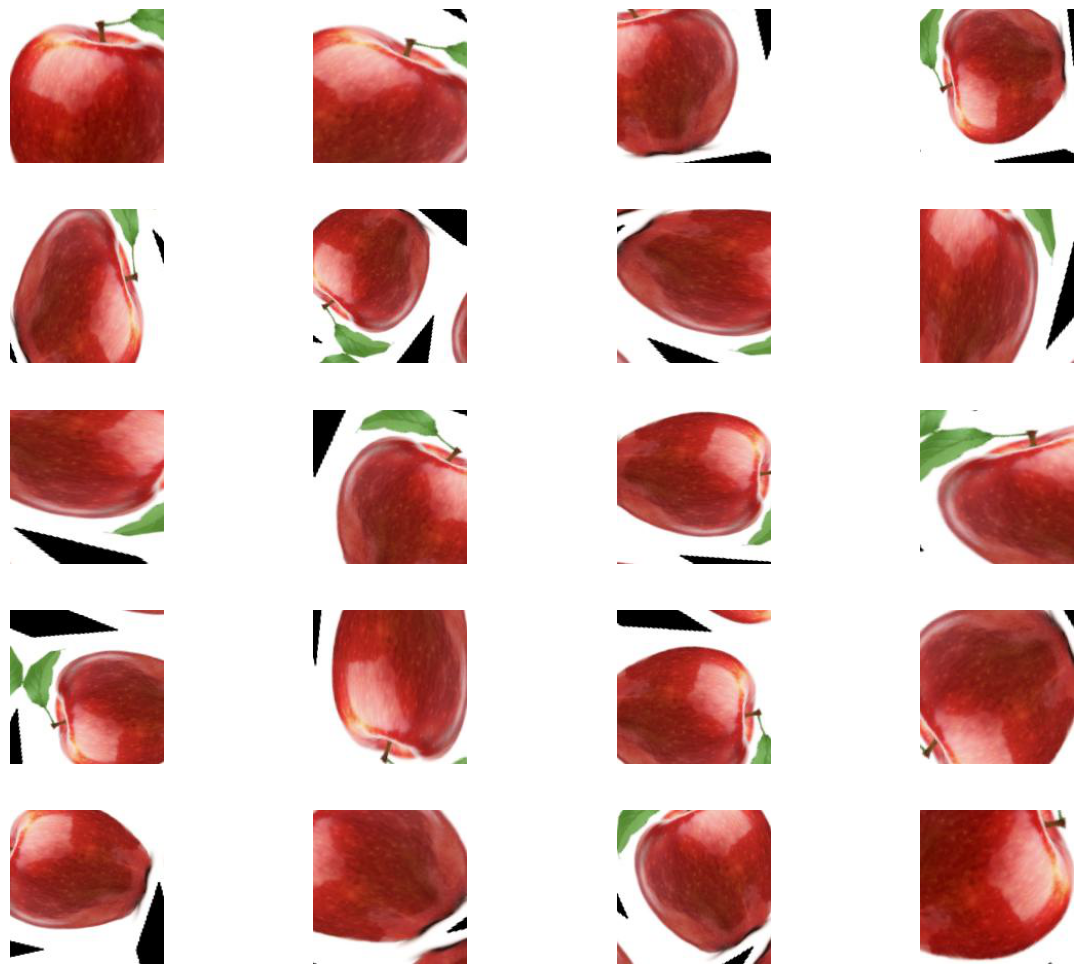

Cleaning up preview files...


In [30]:
import matplotlib.pyplot as plt
import os

preview_dir = './preview_aug'
if not os.path.exists(preview_dir):
    os.mkdir(preview_dir)

# Pick a random image "Fresh" folder to test augmentation
source_folder = os.path.join(train_dir, 'fresh') 
sample_image = os.listdir(source_folder)[0] 
path_aug = os.path.join(source_folder, sample_image)

print(f"Testing augmentation on: {path_aug}")

# Load and Shape the image
img_augmentation = load_img(path_aug, target_size=(150, 150))
x_aug = img_to_array(img_augmentation)
x_aug = x_aug.reshape((1,) + x_aug.shape)

# Generate 20 variations
i = 0
for batch in train_datagen.flow(x_aug, batch_size=1, save_to_dir=preview_dir, save_prefix='fruit', save_format='jpeg'):
    i += 1
    if i >= 20:
        break

# Display the results
preview_img = os.listdir(preview_dir)

plt.figure(figsize=(15, 15))
for n in range(len(preview_img)):
  # Note: Converted the math to int() to avoid errors
  plt.subplot(int(len(preview_img)/4)+1, 4, n+1)
  plt.subplots_adjust(hspace = 0.3)
  
  img_path = os.path.join(preview_dir, preview_img[n])
  plt.imshow(load_img(img_path,
                            color_mode="rgb",
                            target_size=(150, 150),
                            interpolation="nearest"))
  plt.axis('off')
plt.show()


print("Cleaning up preview files...")
for fn in preview_img:
    try:
        os.remove(os.path.join(preview_dir, fn))
    except Exception as e:
        print(f"Could not delete {fn}: {e}")